# ChurnSight - Exploratory Data Analysis
**Project:** Customer Churn Prediction with Explainable AI  
**Dataset:** IBM Telco Customer Churn  
**Author:** Rishitha

## 1. Setup and Data Loading
Loading required libraries and importing the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telco.csv')

# Quick confirmation
print(f"Shape: {df.shape}")
print(f"\nTarget column value counts:")
print(df['Churn Label'].value_counts())
print(f"\nColumn names:")
print(df.columns.tolist())

Shape: (7043, 50)

Target column value counts:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Column names:
['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']


## 2. Column Profiling
Systematically profiling all 50 columns to identify identifiers, leakage columns, and usable features before any analysis.

In [3]:
# Systematically profile every column
profile = []

for col in df.columns:
    profile.append({
        'Column': col,
        'Dtype': df[col].dtype,
        'Unique Values': df[col].nunique(),
        'Unique %': round(df[col].nunique() / len(df) * 100, 2),
        'Missing Count': df[col].isnull().sum(),
        'Missing %': round(df[col].isnull().sum() / len(df) * 100, 2),
        'Sample Values': df[col].dropna().unique()[:3].tolist()
    })

profile_df = pd.DataFrame(profile)
print(profile_df.to_string())

                               Column    Dtype  Unique Values  Unique %  Missing Count  Missing %                                                                            Sample Values
0                         Customer ID      str           7043    100.00              0       0.00                                                     [8779-QRDMV, 7495-OOKFY, 1658-BYGOY]
1                              Gender      str              2      0.03              0       0.00                                                                           [Male, Female]
2                                 Age    int64             62      0.88              0       0.00                                                                             [78, 74, 71]
3                            Under 30      str              2      0.03              0       0.00                                                                                [No, Yes]
4                      Senior Citizen      str              2    

## 3. Dropping Irrelevant and Leakage Columns
Removing columns based on 4 systematic rules: high unique %, zero variance, post-event leakage, and direct target leakage.

In [4]:
# Rule 1: Unique % ~100% - identifier or meaningless aggregate
identifier_cols = ['Customer ID', 'Total Revenue']

# Rule 2: Unique % ~0% - zero variance, same value for all rows
zero_variance_cols = ['Country', 'State', 'Quarter']

# Rule 3: Missing % matches churn rate - post-event leakage
post_event_cols = ['Churn Category', 'Churn Reason']

# Rule 4: Sample values directly reveal the target - direct leakage
direct_leakage_cols = ['Customer Status', 'Churn Score', 'CLTV']

# Geographic cols - too granular, no generalisation value
geo_cols = ['City', 'Zip Code', 'Latitude', 'Longitude', 'Population']

# Combine all and drop
drop_cols = (identifier_cols + zero_variance_cols + post_event_cols + 
             direct_leakage_cols + geo_cols)

df = df.drop(columns=drop_cols)

print(f"Columns dropped: {len(drop_cols)}")
print(f"Shape after dropping: {df.shape}")
print(f"\nRemaining columns:")
print(df.columns.tolist())

Columns dropped: 15
Shape after dropping: (7043, 35)

Remaining columns:
['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Satisfaction Score', 'Churn Label']


## 4. Missing Value Analysis
Identifying and investigating missing values in the remaining 35 columns.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("All columns missing value status:")
print(missing_df.to_string())

All columns missing value status:
                                   Missing Count  Missing %
Gender                                         0       0.00
Age                                            0       0.00
Under 30                                       0       0.00
Senior Citizen                                 0       0.00
Married                                        0       0.00
Dependents                                     0       0.00
Number of Dependents                           0       0.00
Referred a Friend                              0       0.00
Number of Referrals                            0       0.00
Tenure in Months                               0       0.00
Offer                                       3877      55.05
Phone Service                                  0       0.00
Avg Monthly Long Distance Charges              0       0.00
Multiple Lines                                 0       0.00
Internet Service                               0       0.00
Intern

In [6]:
# Investigate Offer missing values
print("=" * 50)
print("OFFER - Missing Investigation")
print("=" * 50)
print(f"Total missing: 3877 (55.05%)")
print(f"\nOffer value counts (non-missing):")
print(df['Offer'].value_counts())

# Investigate Internet Type missing values
print("\n" + "=" * 50)
print("INTERNET TYPE - Missing Investigation")
print("=" * 50)
print(f"Total missing: 1526 (21.67%)")
print(f"\nInternet Type value counts (non-missing):")
print(df['Internet Type'].value_counts())

# Check if Internet Type missing rows match Internet Service = No
print(f"\nRows where Internet Service is No:")
print(df['Internet Service'].value_counts())

print(f"\nInternet Type missing WHERE Internet Service = No:")
no_internet = df[df['Internet Service'] == 'No']
print(f"Count: {no_internet['Internet Type'].isnull().sum()}")

print(f"\nInternet Type missing WHERE Internet Service = Yes:")
yes_internet = df[df['Internet Service'] == 'Yes']
print(f"Count: {yes_internet['Internet Type'].isnull().sum()}")

OFFER - Missing Investigation
Total missing: 3877 (55.05%)

Offer value counts (non-missing):
Offer
Offer B    824
Offer E    805
Offer D    602
Offer A    520
Offer C    415
Name: count, dtype: int64

INTERNET TYPE - Missing Investigation
Total missing: 1526 (21.67%)

Internet Type value counts (non-missing):
Internet Type
Fiber Optic    3035
DSL            1652
Cable           830
Name: count, dtype: int64

Rows where Internet Service is No:
Internet Service
Yes    5517
No     1526
Name: count, dtype: int64

Internet Type missing WHERE Internet Service = No:
Count: 1526

Internet Type missing WHERE Internet Service = Yes:
Count: 0


### 4.1 Handling Missing Values
- **Internet Type:** Missing values correspond exactly to customers with no internet service. Filled with `No Internet`.
- **Offer:** Missing values indicate customers who received no promotional offer. Filled with `No Offer`.

In [7]:
# Internet Type: missing = customer has no internet service
df['Internet Type'] = df['Internet Type'].fillna('No Internet')

# Offer: missing = customer was not given any offer
df['Offer'] = df['Offer'].fillna('No Offer')

# Confirm no missing values remain
print("Missing values after filling:")
print(df.isnull().sum().sum())

print(f"\nInternet Type value counts after fill:")
print(df['Internet Type'].value_counts())

print(f"\nOffer value counts after fill:")
print(df['Offer'].value_counts())

Missing values after filling:
0

Internet Type value counts after fill:
Internet Type
Fiber Optic    3035
DSL            1652
No Internet    1526
Cable           830
Name: count, dtype: int64

Offer value counts after fill:
Offer
No Offer    3877
Offer B      824
Offer E      805
Offer D      602
Offer A      520
Offer C      415
Name: count, dtype: int64


## 5. Univariate Analysis
Exploring the distribution of the target variable and key individual features.

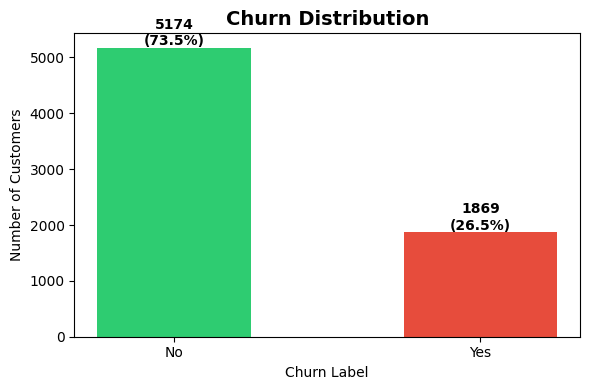

Churned: 1869 (26.5%)
Not Churned: 5174 (73.5%)


In [9]:
plt.figure(figsize=(6, 4))
churn_counts = df['Churn Label'].value_counts()
colors = ['#2ecc71', '#e74c3c']

plt.bar(churn_counts.index, churn_counts.values, color=colors, width=0.5)
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Label')
plt.ylabel('Number of Customers')

for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

print(f"Churned: {churn_counts['Yes']} ({churn_counts['Yes']/len(df)*100:.1f}%)")
print(f"Not Churned: {churn_counts['No']} ({churn_counts['No']/len(df)*100:.1f}%)")

> **Observation:** The dataset is imbalanced with 73.5% non-churned and 26.5% churned customers. 
> Class imbalance will be addressed during model training using class weighting.

### 5.1 Numerical Feature Distributions

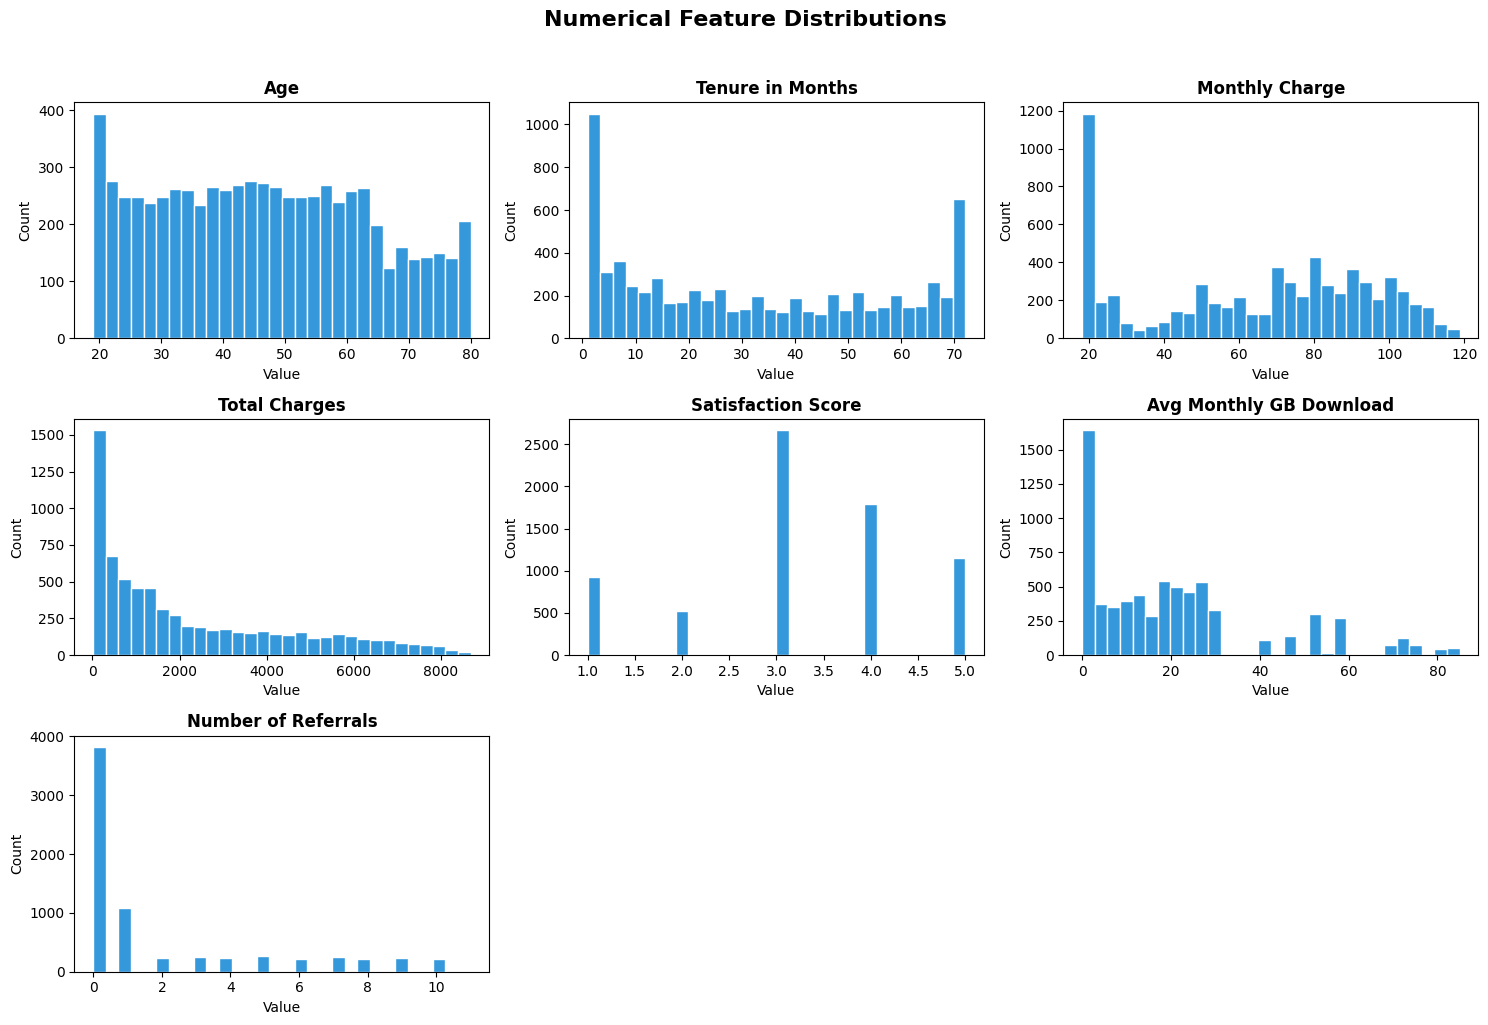

In [11]:
num_cols = ['Age', 'Tenure in Months', 'Monthly Charge', 
            'Total Charges', 'Satisfaction Score', 
            'Avg Monthly GB Download', 'Number of Referrals']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide the empty subplot
axes[7].set_visible(False)
axes[8].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150)
plt.show()

> **Observations:**
> - **Tenure in Months** is bimodal - spike at month 1 (new customers) and month 72 (loyal customers)
> - **Total Charges** is right-skewed, consistent with many short-tenure customers
> - **Satisfaction Score** is ordinal (1-5), score 3 is most frequent
> - **Number of Referrals** is heavily skewed - most customers referred nobody
> - **Avg Monthly GB Download** spikes at 0, consistent with No Internet customers

## 6. Bivariate Analysis
Comparing key features against the Churn Label to identify which features are most associated with churn.

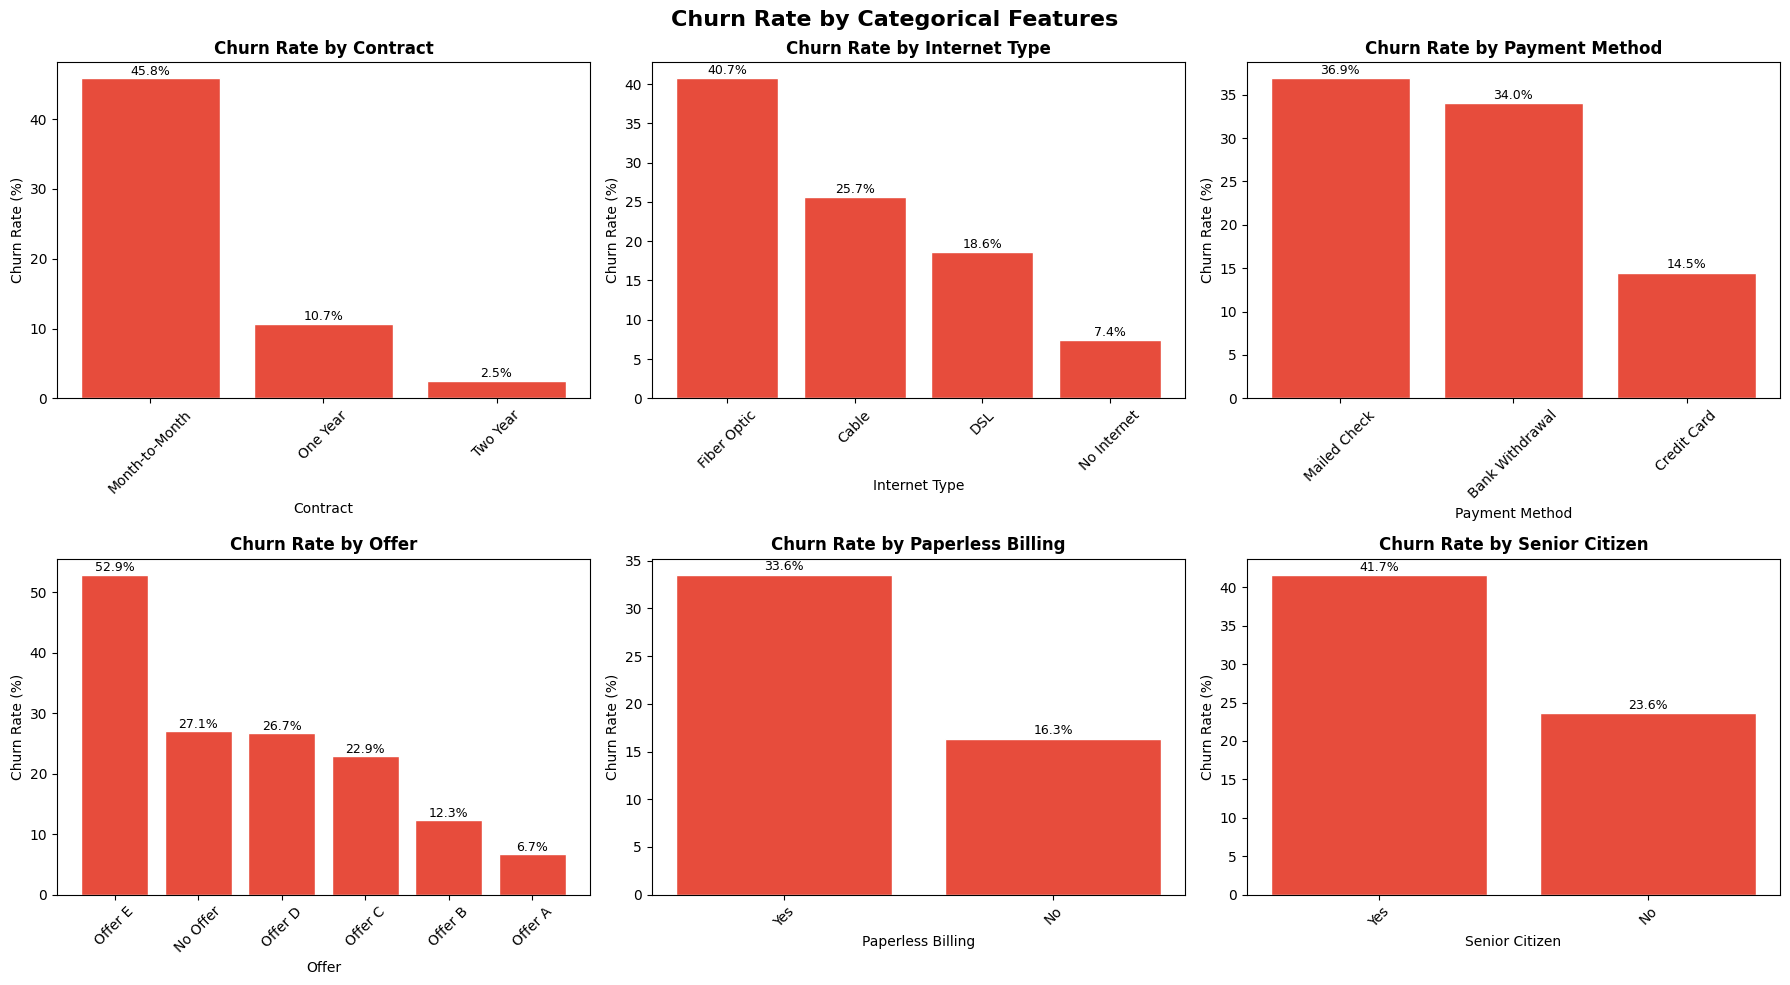

In [12]:
cat_cols = ['Contract', 'Internet Type', 'Payment Method', 
            'Offer', 'Paperless Billing', 'Senior Citizen']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn Label'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    bars = axes[i].bar(churn_rate.index, churn_rate.values, 
                       color='#e74c3c', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)
    
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                     bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Churn Rate by Categorical Features', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_categorical.png', dpi=150)
plt.show()

> **Key Observations:**
> - **Contract type** is the strongest categorical predictor - Month-to-Month customers churn at 45.8% vs 2.5% for Two Year contracts
> - **Fiber Optic** customers have the highest churn (40.7%) despite being on the premium service
> - **Offer A** is the most effective retention offer (6.7% churn) while Offer E is the worst (52.9%)
> - **Senior Citizens** churn significantly more (41.7% vs 23.6%)
> - **Mailed Check** and **Bank Withdrawal** payment methods correlate with higher churn

### 6.1 Churn Rate by Numerical Features

C:\Users\Admin\AppData\Local\Temp\ipykernel_6688\2566591845.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([not_churned, churned],
C:\Users\Admin\AppData\Local\Temp\ipykernel_6688\2566591845.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([not_churned, churned],
C:\Users\Admin\AppData\Local\Temp\ipykernel_6688\2566591845.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([not_churned, churned],
C:\Users\Admin\AppData\Local\Temp\ipykernel_6688\2566591845.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' si

Tenure in Months:
  Churned median: 10.0
  Not Churned median: 38.0

Monthly Charge:
  Churned median: 79.7
  Not Churned median: 64.4

Total Charges:
  Churned median: 703.5
  Not Churned median: 1679.5

Satisfaction Score:
  Churned median: 2.0
  Not Churned median: 4.0

Age:
  Churned median: 50.0
  Not Churned median: 45.0

Number of Referrals:
  Churned median: 0.0
  Not Churned median: 1.0



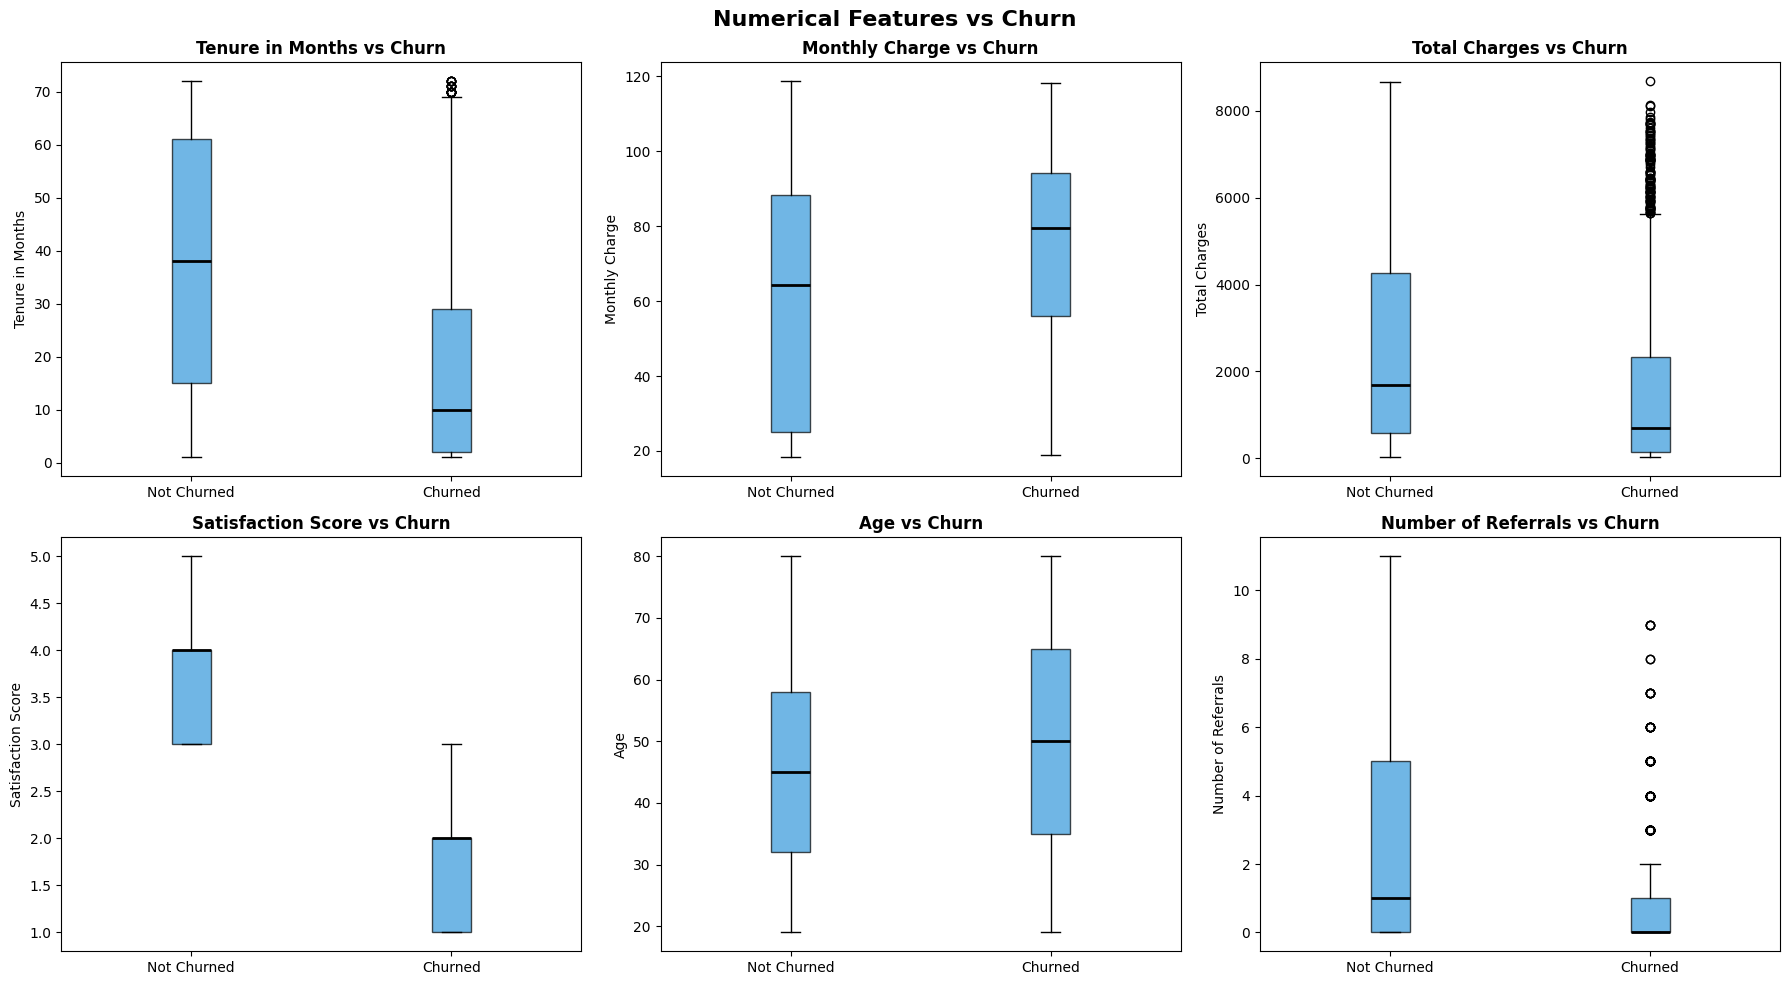

In [13]:
num_cols = ['Tenure in Months', 'Monthly Charge', 
            'Total Charges', 'Satisfaction Score',
            'Age', 'Number of Referrals']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    churned = df[df['Churn Label'] == 'Yes'][col]
    not_churned = df[df['Churn Label'] == 'No'][col]
    
    axes[i].boxplot([not_churned, churned], 
                    labels=['Not Churned', 'Churned'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    
    axes[i].set_title(f'{col} vs Churn', fontweight='bold')
    axes[i].set_ylabel(col)
    
    print(f"{col}:")
    print(f"  Churned median: {churned.median():.1f}")
    print(f"  Not Churned median: {not_churned.median():.1f}\n")

plt.suptitle('Numerical Features vs Churn', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('numerical_vs_churn.png', dpi=150)
plt.show()

> **Key Observations:**
> - **Tenure in Months** shows the strongest separation - churned customers leave at median 10 months vs 38 months for retained customers
> - **Satisfaction Score** has a clear gap - churned customers score 2.0 median vs 4.0 for retained customers
> - **Monthly Charge** is higher for churned customers ($79.7 vs $64.4) - higher charges drive churn
> - **Number of Referrals** median is 0 for churned customers - disengaged customers never refer anyone
> - **Age** shows minimal difference - weak standalone predictor

## 7. Correlation Analysis
Examining correlations between numerical features and identifying multicollinearity.

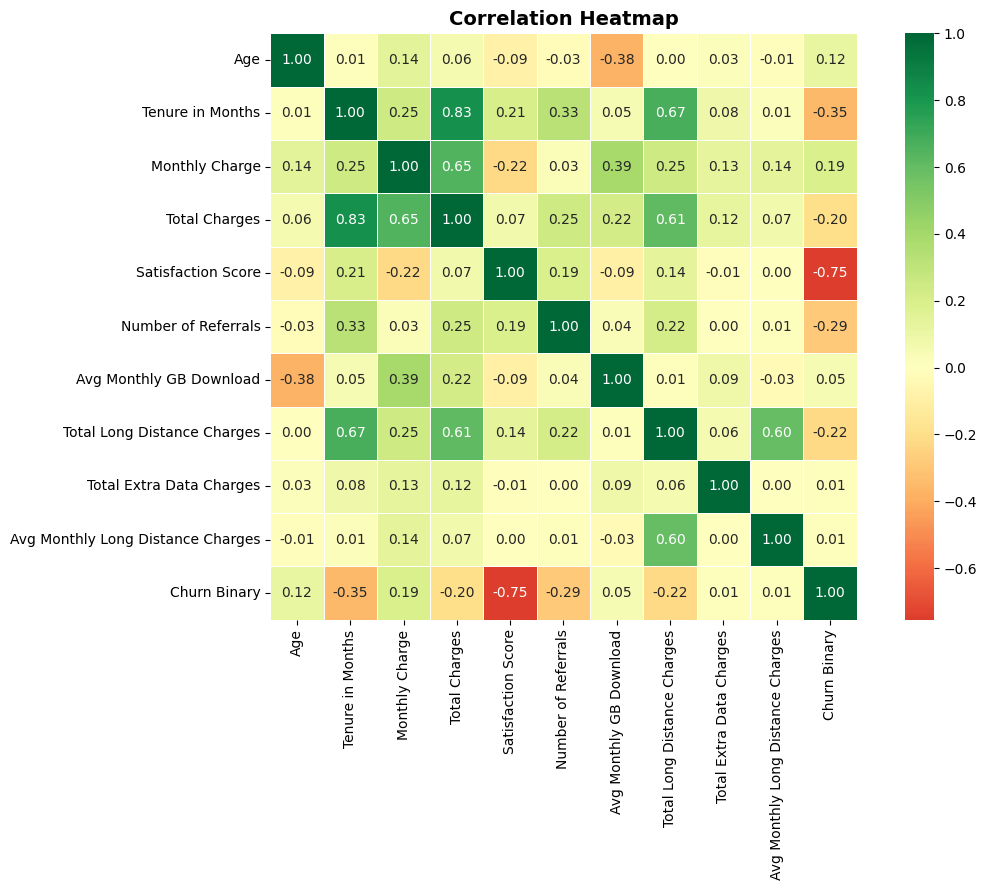

Top correlations with Churn:
Satisfaction Score                  -0.754649
Tenure in Months                    -0.352861
Number of Referrals                 -0.286540
Total Long Distance Charges         -0.223756
Total Charges                       -0.198546
Total Extra Data Charges             0.007139
Avg Monthly Long Distance Charges    0.008120
Avg Monthly GB Download              0.048868
Age                                  0.115760
Monthly Charge                       0.193356
Name: Churn Binary, dtype: float64


In [14]:
# Create binary churn column for correlation
df['Churn Binary'] = (df['Churn Label'] == 'Yes').astype(int)

num_cols_corr = ['Age', 'Tenure in Months', 'Monthly Charge',
                 'Total Charges', 'Satisfaction Score',
                 'Number of Referrals', 'Avg Monthly GB Download',
                 'Total Long Distance Charges', 'Total Extra Data Charges',
                 'Avg Monthly Long Distance Charges', 'Churn Binary']

corr_matrix = df[num_cols_corr].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("Top correlations with Churn:")
print(corr_matrix['Churn Binary'].sort_values().drop('Churn Binary'))

> **Key Observations:**
> - **Satisfaction Score** is the strongest numerical predictor of churn (correlation: -0.75)
> - **Tenure in Months** and **Total Charges** are highly correlated (0.83) - multicollinearity to handle during preprocessing
> - **Monthly Charge** positively correlates with churn (+0.19) - higher bills drive customers away
> - **Number of Referrals** negatively correlates with churn (-0.29) - loyal customers advocate for the brand

## 8. EDA Summary

In [15]:
summary = {
    'Feature': [
        'Satisfaction Score', 'Contract Type', 'Tenure in Months',
        'Offer Type', 'Internet Type', 'Monthly Charge',
        'Number of Referrals', 'Senior Citizen', 'Payment Method',
        'Paperless Billing'
    ],
    'Type': [
        'Numerical', 'Categorical', 'Numerical',
        'Categorical', 'Categorical', 'Numerical',
        'Numerical', 'Categorical', 'Categorical',
        'Categorical'
    ],
    'Key Finding': [
        'Strongest predictor - churned median 2.0 vs 4.0 retained',
        'Month-to-Month 45.8% churn vs Two Year 2.5%',
        'Churned median 10 months vs 38 months retained',
        'Offer E worst (52.9% churn) Offer A best (6.7%)',
        'Fiber Optic highest churn at 40.7%',
        'Churned customers pay more ($79.7 vs $64.4 median)',
        'Churned customers refer nobody (median 0)',
        'Senior citizens churn more (41.7% vs 23.6%)',
        'Mailed Check highest churn (36.9%)',
        'Paperless billing customers churn more (33.6%)'
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

            Feature        Type                                              Key Finding
 Satisfaction Score   Numerical Strongest predictor - churned median 2.0 vs 4.0 retained
      Contract Type Categorical              Month-to-Month 45.8% churn vs Two Year 2.5%
   Tenure in Months   Numerical           Churned median 10 months vs 38 months retained
         Offer Type Categorical          Offer E worst (52.9% churn) Offer A best (6.7%)
      Internet Type Categorical                       Fiber Optic highest churn at 40.7%
     Monthly Charge   Numerical       Churned customers pay more ($79.7 vs $64.4 median)
Number of Referrals   Numerical                Churned customers refer nobody (median 0)
     Senior Citizen Categorical              Senior citizens churn more (41.7% vs 23.6%)
     Payment Method Categorical                       Mailed Check highest churn (36.9%)
  Paperless Billing Categorical           Paperless billing customers churn more (33.6%)


## 9. EDA Conclusions

The exploratory data analysis identified the following key insights that will guide modelling decisions:

**Top Predictors Identified:**
- Satisfaction Score is the strongest numerical predictor (correlation -0.75 with churn)
- Contract Type shows the clearest categorical separation (45.8% vs 2.5% churn rate)
- Tenure in Months confirms early-stage customers are highest risk (median 10 months)
- Offer Type reveals Offer E is ineffective while Offer A retains customers well

**Data Quality Decisions Made:**
- 15 columns dropped due to leakage, zero variance, or identifier nature
- 2 missing value columns filled with meaningful labels (No Internet, No Offer)
- Class imbalance confirmed at 73.5% / 26.5% - will be handled during modelling

**Multicollinearity Noted:**
- Tenure in Months and Total Charges are highly correlated (0.83)
- Will rely on tree-based models (XGBoost, Random Forest) which handle this naturally